In [44]:
import torch
import torch.nn as nn
import numpy as np 
from sklearn import datasets
import matplotlib.pyplot as plt 


X_numpy, Y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

X = torch.from_numpy(X_numpy.astype(np.float32))
Y = torch.from_numpy(Y_numpy.astype(np.float32))
Y=Y.view(Y.shape[0],1)

n_samples, n_features = X.shape


In [45]:
input_size=1
output_size=1
model = nn.Linear(input_size, output_size)

In [46]:
criterion = nn.MSELoss()
learning_rate=0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 100

for epoch in range(num_epochs):
    #forward
    y_pred=model(X)
    loss=criterion(y_pred,Y)
    #backward
    loss.backward()
    #update
    optimizer.step()
    optimizer.zero_grad()

    if (epoch+1) %10 ==0:
        print(f'epoch :{epoch+1}, loss={loss.item():.4f}')

epoch :10, loss=4314.4380
epoch :20, loss=3220.8389
epoch :30, loss=2429.4363
epoch :40, loss=1856.1199
epoch :50, loss=1440.3846
epoch :60, loss=1138.6454
epoch :70, loss=919.4621
epoch :80, loss=760.1252
epoch :90, loss=644.2119
epoch :100, loss=559.8334


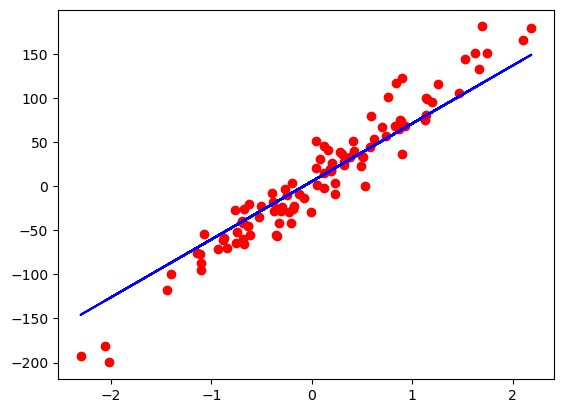

In [47]:
predicted=model(X).detach()
plt.plot(X_numpy, Y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()